# 예측 예제 및 실습

이 노트북은 **`시계열 예측`, `이상 탐지` 기초 예제 실습**을 수행하는 노트북입니다.

✅ 내용  
1. ARIMIA를 활용한 시계열 예측 예제 : 월별 항공 여객수 예측
2. ARIMIA를 활용한 시계열 예측 예제 : 서버 연결 사용자 수 예측
3. Isolation Forest를 활용한 예제 : 신용카드 사기 탐지


In [ ]:
%conda env create -f prediction.yaml -n prediction

### ARIMIA를 활용한 시계열 예측 예제 : 월별 항공 여객수 예측
1949-1960년 월별 항공 여객 수 데이터를 ARIMA(2,1,2) 모델로 학습하여 1961년 12개월간의 승객 수를 예측합니다. 

시계열 데이터의 추세와 계절성을 고려한 차분을 적용하고 자기회귀와 이동평균 성분을 결합하여 미래 값을 예측합니다.

* Kaggle Hub에서 항공 여객 데이터셋을 다운로드하고 pandas로 읽어와 Month 컬럼을 인덱스로 설정하여 시계열 형태로 변환
* matplotlib을 사용하여 1949-1960년 월별 승객 수를 시각화하고 데이터의 상승 추세와 계절성 패턴 확인
* statsmodels 라이브러리를 사용하여 ARIMA(2,1,2) 모델을 생성하고 승객 수 데이터로 학습 수행
* 학습된 모델로 1961년 12개월간의 승객 수를 예측하고 결과를 출력 및 시각화

Path to dataset files: C:\Users\ceo\.cache\kagglehub\datasets\rakannimer\air-passengers\versions\1
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


c:\Users\ceo\miniforge3\envs\ai_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ceo\miniforge3\envs\ai_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ceo\miniforge3\envs\ai_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


예측된 1961년 월별 승객 수:
 1961-01-01    439.855674
1961-02-01    465.297745
1961-03-01    500.667010
1961-04-01    535.971515
1961-05-01    561.688016
1961-06-01    571.310461
1961-07-01    562.969245
1961-08-01    539.726308
1961-09-01    508.526224
1961-10-01    478.147014
1961-11-01    456.748790
1961-12-01    449.699823
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\ceo\miniforge3\envs\ai_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


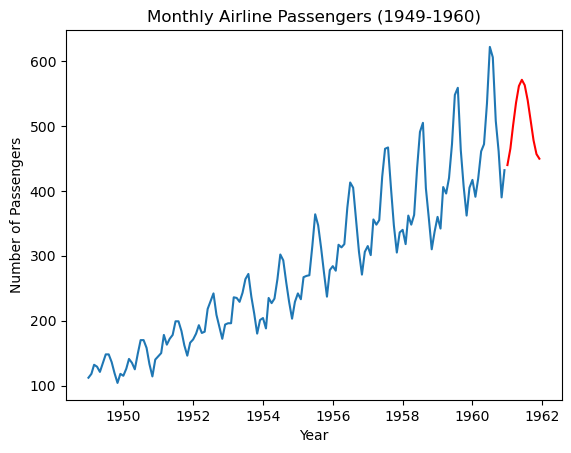

In [1]:
# 1949~1960년 월별 항공 여객 수를 ARIMA(2,1,2)로 예측
#
import kagglehub
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# 1. 데이터 불러오기: 월별 항공 여객 수 데이터 (1949-01 ~ 1960-12)
#https://www.kaggle.com/datasets/rakannimer/air-passengers
path = kagglehub.dataset_download("rakannimer/air-passengers")
print("Path to dataset files:", path)
path = path + '\AirPassengers.csv'
#대체 URL
#path = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(path, parse_dates=['Month'], index_col='Month')
print(df.head())  # 첫 5행 출력하여 데이터 확인

# 2. 시계열 특성 파악: 데이터의 추세와 계절성 확인
import matplotlib.pyplot as plt
plt.plot(df.index, df['#Passengers'])
plt.title("Monthly Airline Passengers (1949-1960)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

# 3. ARIMA 모델 학습: (p,d,q) = (2,1,2)로 설정하여 모델 학습
# 데이터가 뚜렷한 상승 추세와 계절성을 가지므로, d=1 차분 적용 (추세 제거)
model = ARIMA(df['#Passengers'], order=(2, 1, 2))
model_fit = model.fit()

# 4. 향후 12개월 예측 (1961년의 승객 수 예측)
forecast = model_fit.forecast(steps=12)
print("예측된 1961년 월별 승객 수:\n", forecast)
plt.plot(forecast, label='Forecast', color='red')
plt.show()


### ARIMIA를 활용한 시계열 예측 예제 : 서버 연결 사용자 수 예측
웹 서버 연결 사용자 수 데이터를 분 단위 시계열로 변환하고 ACF/PACF 플롯을 통해 최적 ARIMA 파라미터를 탐색합니다. 

선정된 ARIMA(1,1,2) 모델로 학습하여 향후 10분간의 서버 연결 사용자 수를 예측하고 실제값과 비교 시각화합니다.

* Kaggle Hub에서 www-usage 데이터셋을 다운로드하고 WWWusage 컬럼을 분 단위 시계열 객체로 변환
* ACF(자기상관함수)와 PACF(편자기상관함수) 플롯을 생성하여 ARIMA 모델의 p, q 파라미터 최적값 탐색
* 분석 결과를 바탕으로 ARIMA(1,1,2) 모델을 생성하고 서버 사용자 수 데이터로 학습 수행
* 학습된 모델로 향후 10분간의 사용자 수를 예측하고 실제값과 예측값을 시각화하여 성능 평가

Path to dataset files: C:\Users\ceo\.cache\kagglehub\datasets\ukveteran\www-usage\versions\1
Available columns: ['Unnamed: 0', 'time', 'WWWusage']
   Unnamed: 0  time  WWWusage
0           1     1        88
1           2     2        84
2           3     3        85
3           4     4        85
4           5     5        84


C:\Users\ceo\AppData\Local\Temp\ipykernel_10764\3546263434.py:25: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index=pd.date_range(start='2025-07-01', periods=len(data), freq='T')


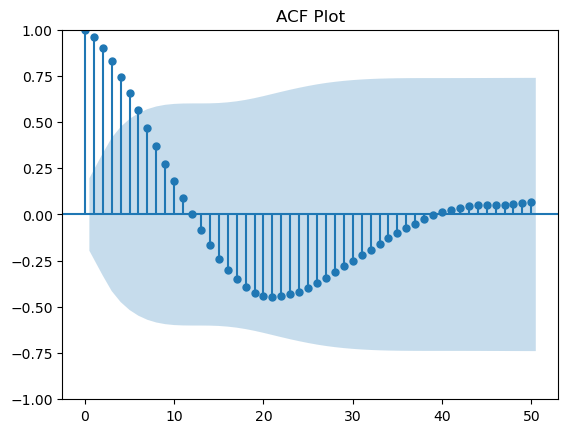

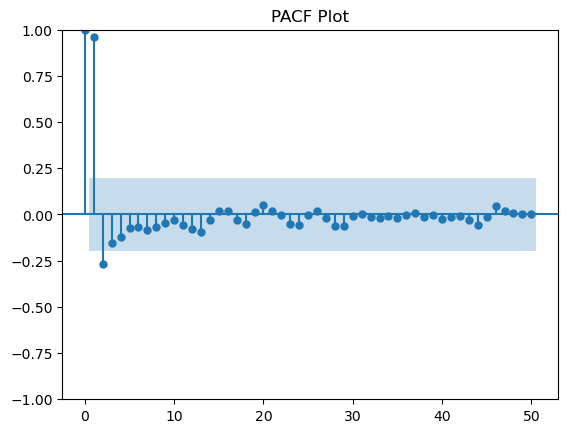

Forecast for next 10 minutes:
 2025-07-01 01:40:00    218.718318
2025-07-01 01:41:00    217.805524
2025-07-01 01:42:00    217.168758
2025-07-01 01:43:00    216.724550
2025-07-01 01:44:00    216.414669
2025-07-01 01:45:00    216.198497
2025-07-01 01:46:00    216.047694
2025-07-01 01:47:00    215.942494
2025-07-01 01:48:00    215.869107
2025-07-01 01:49:00    215.817911
Freq: min, Name: predicted_mean, dtype: float64


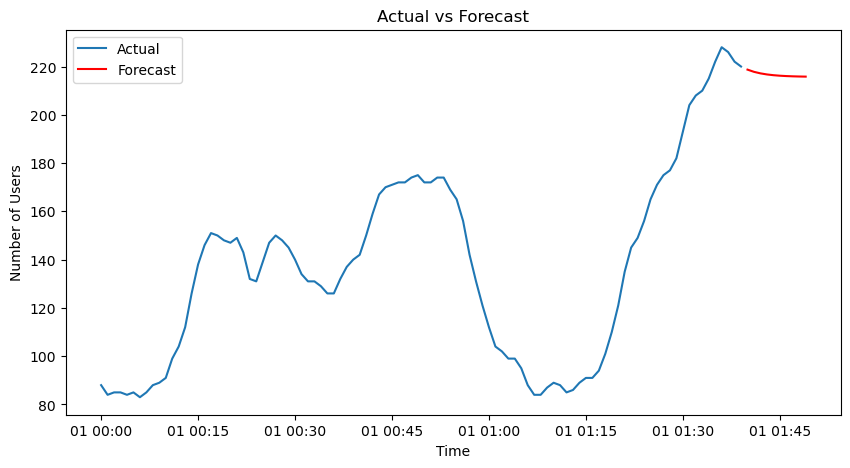

In [2]:
# ARIMA(p,d,q) 파라미터를 선정하기 위해 ACF/PACF 플롯 차트를 시각화하고,
# ARIMA(1,1,2) 모델로 향후 10분 간의 서버 연결 사용자 수를 예측합니다.
import kagglehub
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. 데이터 불러오기: Kaggle 'www-usage' 데이터셋 다운로드 및 파일 경로 설정
#    - 데이터셋 링크: https://www.kaggle.com/datasets/ukveteran/www-usage
path = kagglehub.dataset_download("ukveteran/www-usage")  # Kaggle API를 이용한 데이터 다운로드
print("Path to dataset files:", path)  # 다운로드된 파일 경로 출력
path = path + "\\WWWusage.csv"  # Windows 경로 구분자 사용하여 CSV 파일 지정

# 2. CSV 읽기 및 컬럼 확인
data = pd.read_csv(path)  
print("Available columns:", data.columns.tolist())
print(data.head())

# 3. 시계열 객체 생성
#    - 'WWWusage' 컬럼을 값으로 사용
#    - 2025-07-01 부터 분 단위(freq='T') 인덱스 생성
series = pd.Series(
    data['WWWusage'].values,
    index=pd.date_range(start='2025-07-01', periods=len(data), freq='T')
)

# 4. ACF/PACF 플롯으로 p, q 탐색
plot_acf(series, lags=50)
plt.title("ACF Plot")
plt.show()

plot_pacf(series, lags=50)
plt.title("PACF Plot")
plt.show()

# 5. ARIMA(1,1,2) 모델 학습
model = ARIMA(series, order=(1, 1, 2))
model_fit = model.fit()
#print(model_fit.summary())

# 6. 향후 10단계(10분) 예측
forecast = model_fit.forecast(steps=10)
print("Forecast for next 10 minutes:\n", forecast)

# 7. 실제값 vs 예측값 시각화
plt.figure(figsize=(10,5))
plt.plot(series, label='Actual')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title("Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

### Isolation Forest를 활용한 예제 : 신용카드 사기 탐지
Kaggle 신용카드 사기 데이터셋을 로드하여 IsolationForest 이상치 탐지 모델로 사기 거래를 예측합니다. 

거래 금액을 표준화하고 사기 비율에 따른 contamination 파라미터를 설정하여 정상 거래와 사기 거래를 분류하고 성능을 평가합니다.

* Kaggle Hub에서 신용카드 사기 데이터셋을 다운로드하고 정상 거래와 사기 거래의 분포를 확인
* Time과 Class 컬럼을 제거하고 Amount 컬럼을 StandardScaler로 표준화하여 모델 입력 특성 준비
* 사기 거래 비율을 contamination 파라미터로 설정하여 IsolationForest 모델을 생성하고 학습 수행
* 학습된 모델로 이상치 예측을 수행하고 결과를 사기(1)와 정상(0) 이진 레이블로 변환
* 혼동행렬과 분류 리포트를 생성하여 precision, recall, f1-score 등의 성능 지표로 모델 평가

In [39]:
#신용카드 거래 사기 예측 예제
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

#1. 데이터 로드
#    - 데이터셋 링크: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")  # Kaggle API를 이용한 데이터 다운로드
print("Path to dataset files:", path)  # 다운로드된 파일 경로 출력
path = path + "\\creditcard.csv"  # Windows 경로 구분자 사용하여 CSV 파일 지정
df = pd.read_csv(path)

# 데이터의 크기 확인: (행 개수, 열 개수)
print("데이터셋 크기:", df.shape)  
# Class 컬럼의 값 분포 확인: 정상(0) 거래 vs 사기(1) 거래 개수
print("Class 분포:\n", df['Class'].value_counts(), "\n")

# 2. 특성 선택 및 정규화
# Time 컬럼은 거래 시점 정보이지만, 본 예제에서는 제외합니다.
# Class 컬럼은 레이블 정보이므로 모델 입력에서는 제거합니다.
X = df.drop(columns=['Time', 'Class'])

# Amount(거래 금액)는 원 단위 스케일이 매우 크므로 모델 학습 전 표준화가 필요합니다.
scaler = StandardScaler()
# Amount 컬럼을 2차원 배열로 변환하여 fit_transform 수행
X['ScaledAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 원본 Amount 컬럼은 더 이상 사용하지 않으므로 삭제
X = X.drop(columns=['Amount'])

# 3. IsolationForest 모델 설정 및 학습
# contamination: 데이터 중 어느 정도 비율을 이상(사기)치로 결정할지에 대한 비율을 지정 (사기 비율 ≈ 전체에서 1의 평균)
contamination = df['Class'].mean()

# IsolationForest 인스턴스 생성
# - contamination: 이상치 비율
# - random_state: 재현성을 위한 시드
# - n_jobs=-1: 가능한 모든 CPU 코어를 사용하여 학습 속도 향상
model = IsolationForest(
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

# 학습: 전체 특성 데이터 X를 사용하여 모델을 학습시킵니다.
model.fit(X)

# 4. 이상치 예측 수행
# predict 메서드는 이상치로 판단된 샘플에 -1, 정상 샘플에 1을 반환합니다.
y_pred_if = model.predict(X)

# -1 → 사기(1), 1 → 정상(0) 로 이진 분류 레이블로 변환
y_pred = [1 if pred == -1 else 0 for pred in y_pred_if]

# 5. 평가 지표 계산
# 실제 레이블 (0: 정상, 1: 사기)
y_true = df['Class'].values

# (1) 탐지된 이상치 인덱스 리스트 생성
anomaly_indices = [i for i, p in enumerate(y_pred) if p == 1]

# (2) 탐지된 이상치 중 실제 사기 거래 개수 계산
detected_frauds = sum(y_true[i] == 1 for i in anomaly_indices)

# (3) 탐지된 이상치 중 정상 거래(오탐) 개수 계산
false_alarms = sum(y_true[i] == 0 for i in anomaly_indices)

# 결과 출력
print(f"이상치로 탐지된 거래 수: {len(anomaly_indices)}")
print(f"→ 실제 사기 거래로 탐지된 수: {detected_frauds}")
print(f"→ 정상 거래를 오탐지한 수: {false_alarms}\n")

# 6. 혼동행렬 및 분류 리포트로 모델 성능 종합 평가
# confusion_matrix: 실제 레이블과 예측 레이블을 비교하여 2x2 매트릭스 생성
cm = confusion_matrix(y_true, y_pred)
print("혼동행렬:\n", cm, "\n")

# classification_report: precision, recall, f1-score, support 등을 출력
print("분류 리포트:\n", classification_report(y_true, y_pred, digits=4))

Path to dataset files: C:\Users\ceo\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
데이터셋 크기: (284807, 31)
Class 분포:
 Class
0    284315
1       492
Name: count, dtype: int64 

이상치로 탐지된 거래 수: 492
→ 실제 사기 거래로 탐지된 수: 139
→ 정상 거래를 오탐지한 수: 353

혼동행렬:
 [[283962    353]
 [   353    139]] 

분류 리포트:
               precision    recall  f1-score   support

           0     0.9988    0.9988    0.9988    284315
           1     0.2825    0.2825    0.2825       492

    accuracy                         0.9975    284807
   macro avg     0.6406    0.6406    0.6406    284807
weighted avg     0.9975    0.9975    0.9975    284807

